In [1]:
"""
===========================================
Tutorial 3: Benchmarking multiple pipelines
===========================================

In this last part, we extend the previous example by assessing the
classification score of not one but three classification pipelines.
"""

# Authors: Pedro L. C. Rodrigues, Sylvain Chevallier
#
# https://github.com/plcrodrigues/Workshop-MOABB-BCI-Graz-2019

import warnings

import matplotlib.pyplot as plt
import mne
import seaborn as sns
from mne.decoding import CSP
from pyriemann.classification import MDM
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

import moabb
from moabb.datasets import BNCI2014_001, Zhou2016
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import LeftRightImagery


mne.set_log_level("CRITICAL")
moabb.set_log_level("info")
warnings.filterwarnings("ignore")

In [2]:
##############################################################################
# Creating Pipelines
# ------------------
#
# We instantiate the three different classiciation pipelines to be considered
# in the analysis. The object that gathers each pipeline is a dictionary. The
# first pipeline is the CSP+LDA that we have seen in the previous parts. The
# other two pipelines rely on Riemannian geometry, using an SVM classification
# in the tangent space of the covariance matrices estimated from the EEG or a
# MDM classifier that works directly on covariance matrices.

pipelines = {}
pipelines["csp+lda"] = make_pipeline(CSP(n_components=8), LDA())
pipelines["tgsp+svm"] = make_pipeline(
    Covariances("oas"), TangentSpace(metric="riemann"), SVC(kernel="linear")
)
pipelines["MDM"] = make_pipeline(Covariances("oas"), MDM(metric="riemann"))

In [3]:
##############################################################################
# The following lines go exactly as in the previous tutorial, where we end up
# obtaining a pandas dataframe containing the results of the evaluation.
datasets = [BNCI2014_001(), Zhou2016()]
subj = [1, 2, 3]
for d in datasets:
    d.subject_list = subj
paradigm = LeftRightImagery()
evaluation = WithinSessionEvaluation(
    paradigm=paradigm, datasets=datasets, overwrite=False
)
results = evaluation.process(pipelines)

Zhou2016-WithinSession: 100%|██████████| 3/3 [00:07<00:00,  2.43s/it]
2025-12-19 08:54:11,058 INFO MainThread moabb.evaluations.base tgsp+svm | BNCI2014-001 | 1 | 0train: Score 0.923
2025-12-19 08:54:11,119 INFO MainThread moabb.evaluations.base MDM | BNCI2014-001 | 1 | 0train: Score 0.933
2025-12-19 08:54:11,169 INFO MainThread moabb.evaluations.base tgsp+svm | BNCI2014-001 | 1 | 1test: Score 0.956
2025-12-19 08:54:11,222 INFO MainThread moabb.evaluations.base MDM | BNCI2014-001 | 1 | 1test: Score 0.942
2025-12-19 08:54:11,272 INFO MainThread moabb.evaluations.base tgsp+svm | BNCI2014-001 | 2 | 0train: Score 0.692
2025-12-19 08:54:11,324 INFO MainThread moabb.evaluations.base MDM | BNCI2014-001 | 2 | 0train: Score 0.604
2025-12-19 08:54:11,372 INFO MainThread moabb.evaluations.base tgsp+svm | BNCI2014-001 | 2 | 1test: Score 0.592
2025-12-19 08:54:11,428 INFO MainThread moabb.evaluations.base MDM | BNCI2014-001 | 2 | 1test: Score 0.536
2025-12-19 08:54:11,479 INFO MainThread moabb.eval

2025-12-19 08:54:25,890 INFO MainThread matplotlib.category Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-12-19 08:54:25,894 INFO MainThread matplotlib.category Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


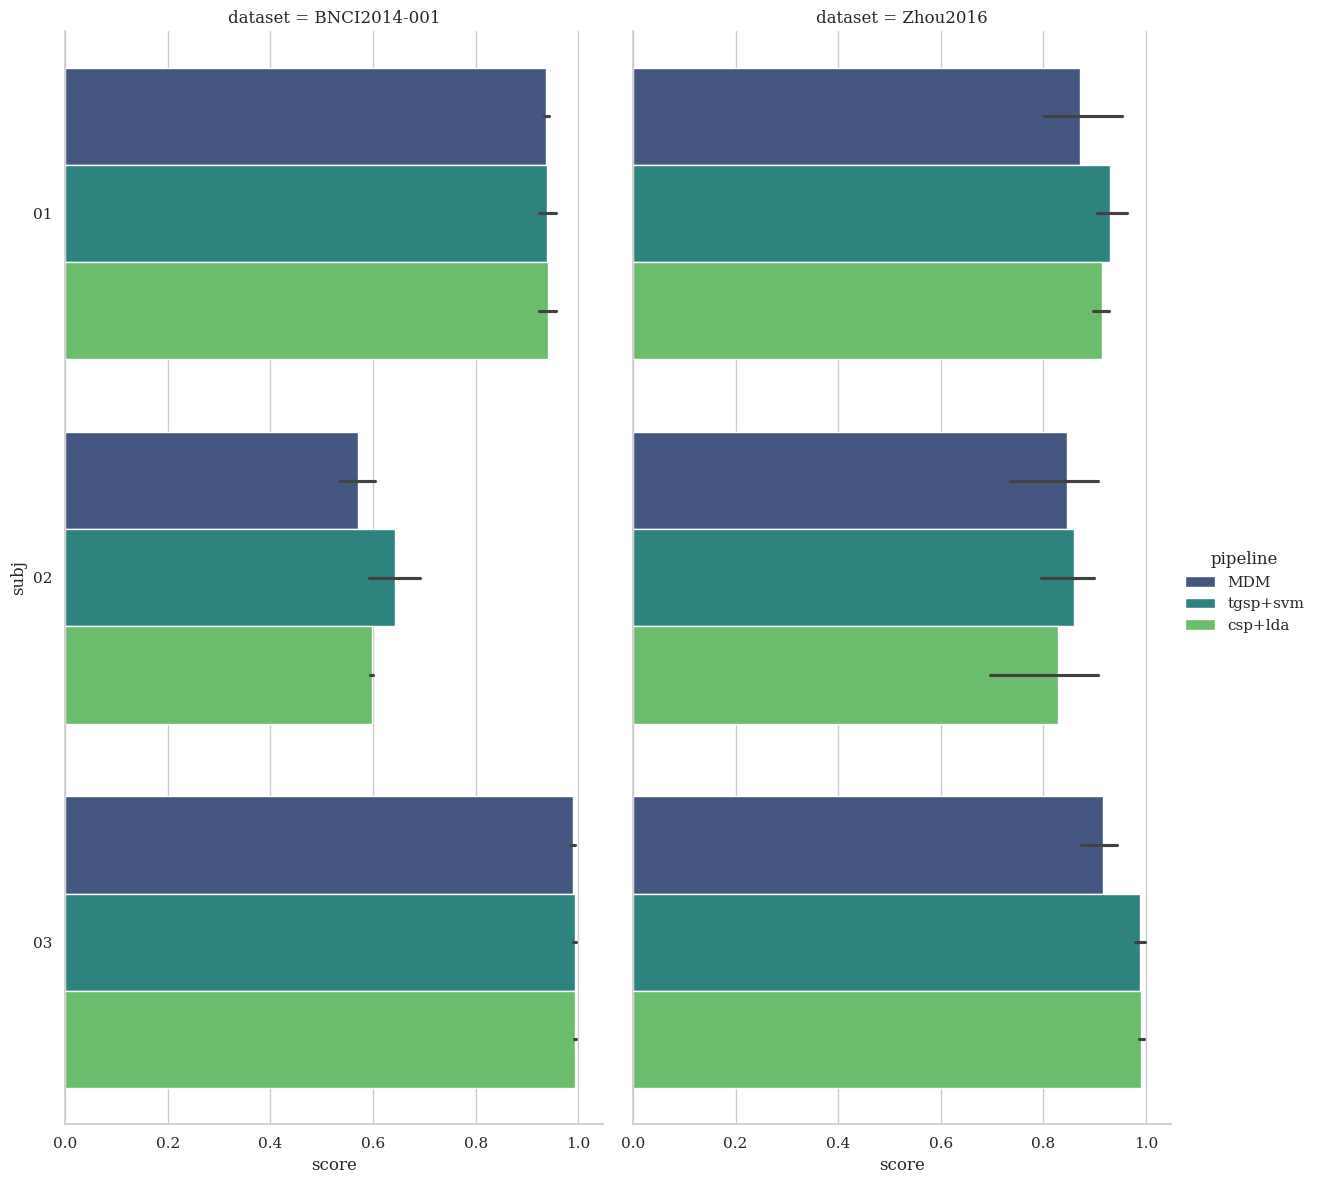

In [4]:
##############################################################################
# As `overwrite` is set to False, the results from the previous tutorial are reused and
# only the new pipelines are evaluated. The results from "csp+lda" are not recomputed.
# The results are saved in ~/mne_data/results if the parameter `hdf5_path` is not set.

##############################################################################
# Plotting Results
# ----------------
#
# The following plot shows a comparison of the three classification pipelines
# for each subject of each dataset.

results["subj"] = [str(resi).zfill(2) for resi in results["subject"]]
g = sns.catplot(
    kind="bar",
    x="score",
    y="subj",
    hue="pipeline",
    col="dataset",
    height=12,
    aspect=0.5,
    data=results,
    orient="h",
    palette="viridis",
)
plt.show()